In [33]:

from pymongo import MongoClient
import pandas as pd

try: 
    client = MongoClient("localhost", 27017)
    print("Connected successfully!!!") 
except:
    print("Could not connect to MongoDB")

db = client["flask_db"]
activity = db.activity



Connected successfully!!!


In [67]:
project_ids = (
    "656fadd102ae94a7686aae62",
    "640e22cae918523bcee8ca5e",
    "6543b8ee4180527babd20c3a",
    "656a440644dec9f71f2dee44",
    "654682f220e7d557c7e67cff",
    "6470fc81c8542274b9582aa1"
)

project_id = project_ids[1]
#project_id = "6516fce1459696e2363e98ef"

query = {"project": project_id, "editingLines": {"$exists": True, "$ne": None}}

cursor = activity.find(query)

df = pd.DataFrame(list(cursor))
#df = df.astype({"text": str, "state": str, "line": str, "username": str, "project": str, "file": str, "message": str})

col_names = df.columns.tolist()
dtypes = df.dtypes
df.head()

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,changes,clipboard,cb
0,654d2792542f9d340fc27e58,1699555217932,The attribute model $p(a|x)$ yields a scalar p...,"[[0, The attribute model $p(a|x)$ yields a sca...",Typing,146,karin,640e22cae918523bcee8ca5e,emnlp2023.tex,"[132, 133, 134, 135, 136, 137, 138, 139, 140, ...",Typing,"[(146,799), ---added]",NaN,NaN
1,655bac3ed2c19708d535655c,1700506686410,% Author 1 \\ {\bf Author 2} \\ ... \\...,"[[0, % Author 1 \\ {\bf Author 2} \\ ....",Typing,76,karin,640e22cae918523bcee8ca5e,emnlp2023.tex,"[51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 6...",Typing,"[(76,12), important->in]",NaN,NaN
2,655bd6cbd2c19708d53565c5,1700517579571,%\setlength\titlebox{<dim>}\n%\n% and set <dim...,"[[0, %\setlength\titlebox{<dim>}\n%\n% and set...",Typing,76,karin,640e22cae918523bcee8ca5e,emnlp2023.tex,"[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 5...",Typing,"[(76,735), Our baseline is a plug-and-play app...",NaN,NaN
3,655bd6ccd2c19708d53565c6,1700517580041,%\setlength\titlebox{<dim>}\n%\n% and set <dim...,"[[0, %\setlength\titlebox{<dim>}\n%\n% and set...",Typing,76,karin,640e22cae918523bcee8ca5e,emnlp2023.tex,"[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 5...",Typing,"[(76,736), e ---added]",NaN,NaN
4,655bd6ced2c19708d53565c7,1700517582596,%\setlength\titlebox{<dim>}\n%\n% and set <dim...,"[[0, %\setlength\titlebox{<dim>}\n%\n% and set...",Typing,76,karin,640e22cae918523bcee8ca5e,emnlp2023.tex,"[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 5...",Typing,"[(76,738), demonstrate t---added]",NaN,NaN


In [35]:
print("column names", col_names)
print("num rows", len(df))

print("average len", df["editingLines"].apply(len).mean())
print("median len", df["editingLines"].apply(len).median())
print("mode len", df["editingLines"].apply(len).mode().tolist())

column names ['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username', 'project', 'file', 'editingLines', 'message', 'changes', 'clipboard', 'cb']
num rows 30243
average len 40.371887709552624
median len 37.0
mode len [35]


In [36]:
print("unique files in project", df["file"].unique())

unique files in project ['introduction.tex' 'acl_latex.tex' 'images' 'latex' 'simulation.tex'
 'instruction.tex' 'tasklabels.tex' 'freetext.tex' 'preference.tex'
 'acl_natbib.bst' 'bibtex' 'human_raters.bib' 'free_form_text.bib'
 'instructions.bib' 'overview.tex' 'pref_eval.bib' 'discussion.tex'
 'pref_eval' 'human_raters' 'simulation' 'wass_trend.pdf'
 'data_explanation_appendix.tex' 'exp_results.tex' 'main.tex'
 'instructions' 'simulation.bib' 'appendix.tex' 'icons'
 'freetext_appendix.tex' 'data_types.tex' 'exp_results_2.tex' 'free_text'
 'methods.tex' 'contributions.tex' 'custom.bib' 'all_refs.bib'
 'minted.sty']


In [37]:
df1 = df["username"].value_counts().sort_values()
df["line_counts"] = df["editingLines"].apply(len)

df2 = df.groupby(["username"])["line_counts"].sum().sort_values()
print(df.head())

print(df1)
print(df2)


                        _id      timestamp  \
0  65708e17ea0333c46f1ce0d5  1701875222539   
1  65710cb4ea0333c46f1ce11f  1701907635170   
2  65710cbfea0333c46f1ce120  1701907646740   
3  65710cc0ea0333c46f1ce121  1701907647197   
4  65710cc0ea0333c46f1ce122  1701907648145   

                                                text  \
0                                                      
1  %I change the title to be more NLP-ish - Shirl...   
2  %I change the title to be more NLP-ish - Shirl...   
3  %I change the title to be more NLP-ish - Shirl...   
4  %I change the title to be more NLP-ish - Shirl...   

                                            revision   state line  \
0  [[-1, % This must be in the first 5 lines to t...  Typing    1   
1  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
2  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
3  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
4  [[0, %I change the title to be more NL

['das00015@umn.edu' 'karin' 'lee03533@umn.edu' 'debaratidas'
 'hu000562@umn.edu' 'mart5877@umn.edu' 'Zae' 'owan0002@umn.edu'
 'hayat023@umn.edu' 'Zae Myung' 'Minhwa']


/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_96673/3593406568.py:15: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_96673/3593406568.py:20: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



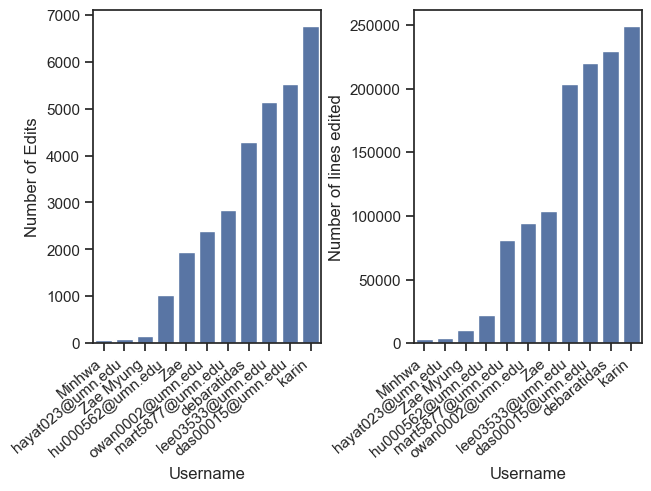

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import colorcet as cc

sns.set_theme(style="ticks")

print(df["username"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True) 

ax1 = sns.barplot(df1, ax=ax1)
ax1.set(xlabel='Username', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")


ax2 = sns.barplot(df2, ax=ax2)
ax2.set(xlabel="Username", ylabel="Number of lines edited")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_fig.png")




In [39]:
def count_op(op, revision):
    count = 0
    
    for l in revision:
        curr_op = l[0]

        if (op is None):
            count += len(l[1])
        if curr_op == op:
            count += op * len(l[1])

    return count
        

/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_96673/45329987.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



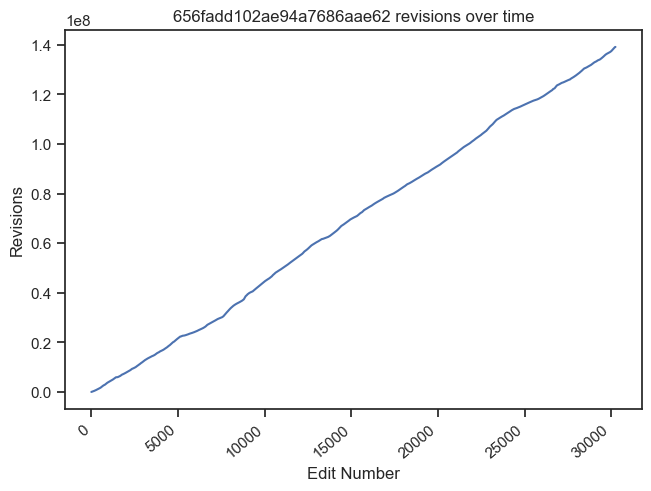

In [40]:
#df["edits"] = df["revision"].apply(len)
df["edits"] = df.apply(lambda x: count_op(None, x["revision"]), axis=1)

df["cum_edits"] = df["edits"].cumsum()

fig, ax = plt.subplots(1, 1, constrained_layout = True) 

ax = sns.lineplot(df["cum_edits"], ax=ax)
ax.set(xlabel='Edit Number', ylabel='Revisions')
ax.set_title(f"{project_id} revisions over time")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_revisions_fig.png")


# File edits across time

Currenly only showing .tex or .bib files

Index([1701875222539, 1701907635170, 1701907646740, 1701907647197,
       1701907648145, 1701907648862, 1701907649662, 1701907650072,
       1701907653784, 1701907654542,
       ...
       1706252324811, 1706252363623, 1706252405838, 1706252506838,
       1706252526447, 1706252818954, 1706252993652, 1706253002221,
       1706253409591, 1707609499738],
      dtype='int64', name='timestamp', length=29763)


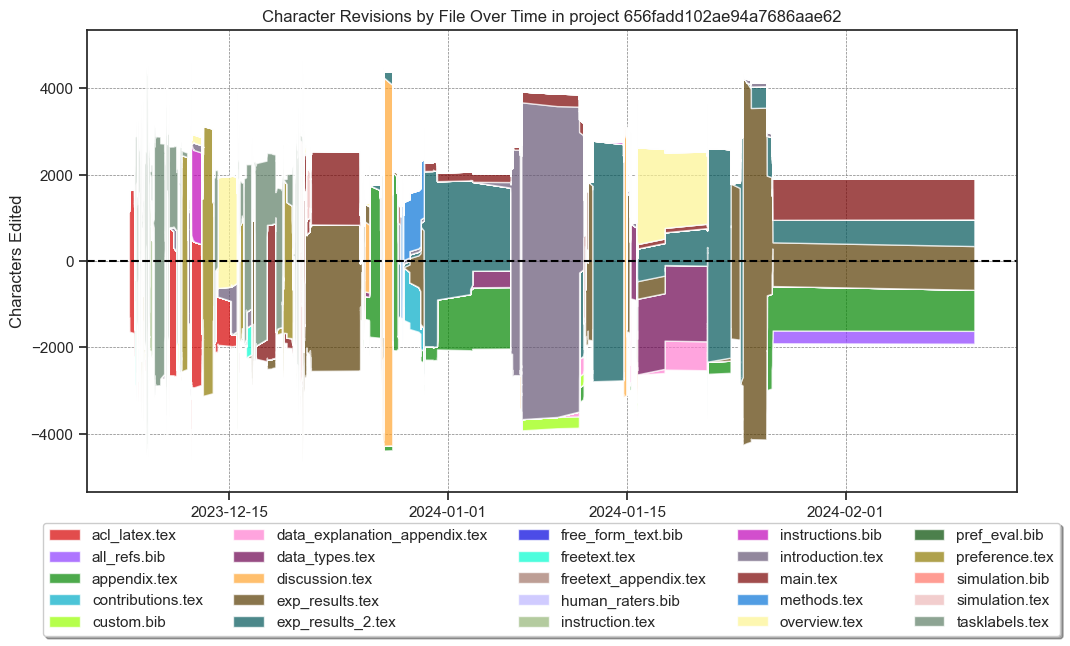

In [41]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Characters Edited')
ax.set_title(f'Character Revisions by File Over Time in project {project_id}')
ax.set_ylim((-5350, 5350))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)
#ax.set_yscale("symlog")


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_revisions_stackplot.png")


Index([1701875222539, 1701907635170, 1701907646740, 1701907647197,
       1701907648145, 1701907648862, 1701907649662, 1701907650072,
       1701907653784, 1701907654542,
       ...
       1706252324811, 1706252363623, 1706252405838, 1706252506838,
       1706252526447, 1706252818954, 1706252993652, 1706253002221,
       1706253409591, 1707609499738],
      dtype='int64', name='timestamp', length=29763)


file,acl_latex.tex,all_refs.bib,appendix.tex,contributions.tex,custom.bib,data_explanation_appendix.tex,data_types.tex,discussion.tex,exp_results.tex,exp_results_2.tex,...,instructions.bib,introduction.tex,main.tex,methods.tex,overview.tex,pref_eval.bib,preference.tex,simulation.bib,simulation.tex,tasklabels.tex
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-06 15:07:02.539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-07 00:07:15.170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-07 00:07:26.740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-07 00:07:27.197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-07 00:07:28.145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


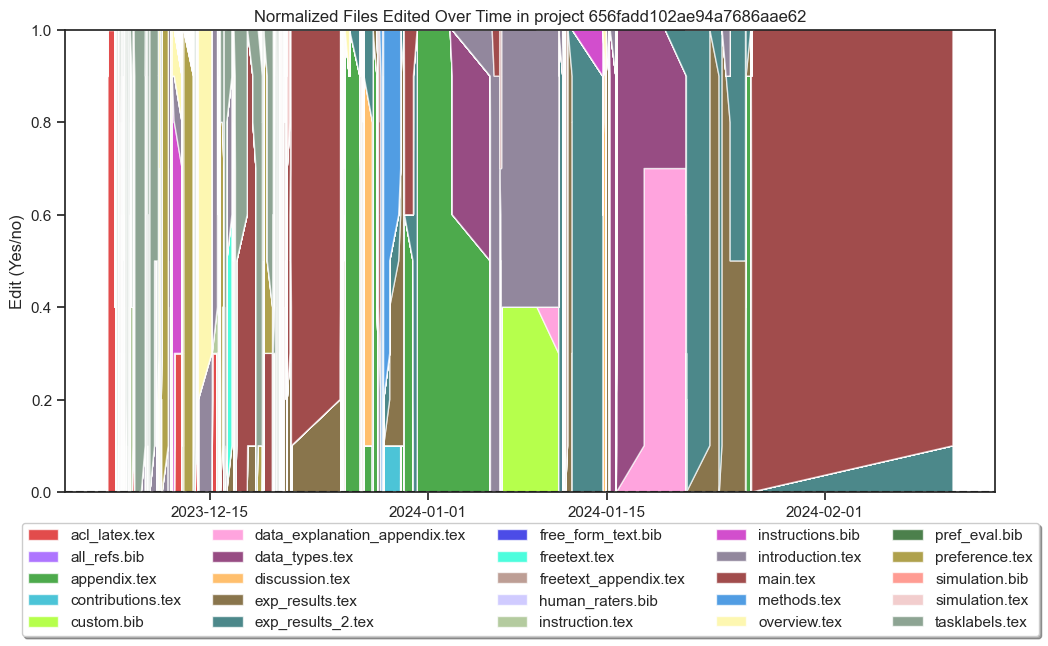

In [66]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="size", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 10  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_title(f'Normalized Files Edited Over Time in project {project_id}')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit (Yes/no)')
#ax.set_title('Edit (Yes/no)')
ax.set_ylim((0, 1))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_file_edits_stackplot.png")

pivot_df.head()

In [43]:
import diff_match_patch as dmp_module

dmp = dmp_module.diff_match_patch()

state
Typing      27145
Paste        1521
Copy          970
UndoRedo      307
Cut           266
Scroll         22
Switch         11
Undoredo        1
Name: count, dtype: int64


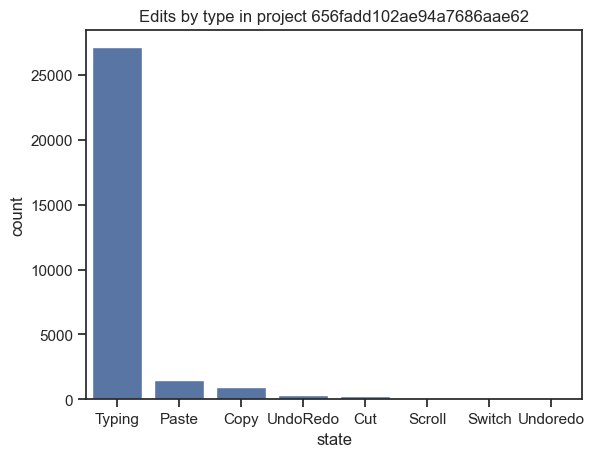

In [44]:
data = df["state"].value_counts()
print(data)
sns.barplot(data).set_title(f'Edits by type in project {project_id}')

fig.savefig(f"figures/{project_id}_edits_by_type.png")



In [45]:
idx = 12

print(df.iloc[idx]["state"])
print(df.iloc[idx]["file"])
print(df.iloc[idx]["text"])
print(df.iloc[idx]["revision"])
print("\nLen:", len(df.iloc[idx]["revision"]))
df.head()

Typing
acl_latex.tex
%I change the title to be more NLP-ish - Shirley

% Author information can be set in various styles:
% For several authors from the same institution:
% \author{anonymous}\and ... \and Author n \\
%         Address line \\ ... \\ Address line}
% if the names do not fit well on one line use
%         Author 1 \\ {\bf Author 2} \\ ... \\ {\bf Author n} \\
% For authors from different institutions:
% \author{anonymous}\\ Address line \\  ... \\ Address line
%         \And  ... \And
%         Author n \\ Address line \\ ... \\ Address line}
% To start a separate ``row'' of authors use \AND, as in
% \author{anonymous}\\ Address line \\  ... \\ Address line
%         \AND
%         Author 2 \\ Address line \\ ... \\ Address line \And
%         Author 3 \\ Address line \\ ... \\ Address line}

\author{anonymous}

\begin{document}
\maketitle
\begin{abstract}
Insert abstract here
\end{abstract}

\section{Introduction}
\begin{figure}
    \centering
    \includegraphics[width=

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,changes,clipboard,cb,line_counts,edits,cum_edits
0,65708e17ea0333c46f1ce0d5,1701875222539,,"[[-1, % This must be in the first 5 lines to t...",Typing,1,das00015@umn.edu,656fadd102ae94a7686aae62,introduction.tex,[1],Typing,"[(1,0), % This must be in the first 5 lines to...",NaN,NaN,1,2790,2790
1,65710cb4ea0333c46f1ce11f,1701907635170,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \n---added]",NaN,NaN,79,2312,5102
2,65710cbfea0333c46f1ce120,1701907646740,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }---added]",NaN,NaN,79,2325,7427
3,65710cc0ea0333c46f1ce121,1701907647197,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }->\karin{DebL}]",NaN,NaN,79,2325,9752
4,65710cc0ea0333c46f1ce122,1701907648145,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL}->\karin{Deb: ]",NaN,NaN,79,2326,12078


In [46]:
import re

def get_section_edited(text, line, editingLines):
    edit_line = int(line)

    matches = list(re.finditer("\\\\section", text))

    if not matches:
        return None

    end = matches[-1].start()
    # -1 so a failed 'rfind' maps to the first line.
    newline_table = {-1: 0}
    for i, m in enumerate(re.finditer('\\n', text), 1):
        # Don't find newlines past our last match.
        offset = m.start()
        if offset > end:
            break
        newline_table[offset] = i

    matches_idx = []
    
    for m in matches:
        newline_offset = text.rfind('\n', 0, m.start())
        newline_end = text.find('\n', m.end())  # '-1' gracefully uses the end.
        line = text[newline_offset + 1:newline_end]
        line_number = newline_table[newline_offset]
        #print (line_number, line)

        matches_idx.append((line_number, line))

    if (len(matches_idx) == 0):
        #print("no matches", matches_idx)
        return None
    elif (edit_line < matches_idx[0][0]):
        return "no section"
        #raise Exception("too early")
    else:
        #print("edit_line", edit_line, "output:", next(((line_number, line) for (line_number, line) in matches_idx if line_number < edit_line), 0))
        string = next((line for (line_number, line) in matches_idx if line_number < edit_line), 0)
        if (isinstance(string, str)):
            return string[string.find("{")+1:string.find("}")]
        else:
            return None
        

    

/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_96673/192113333.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



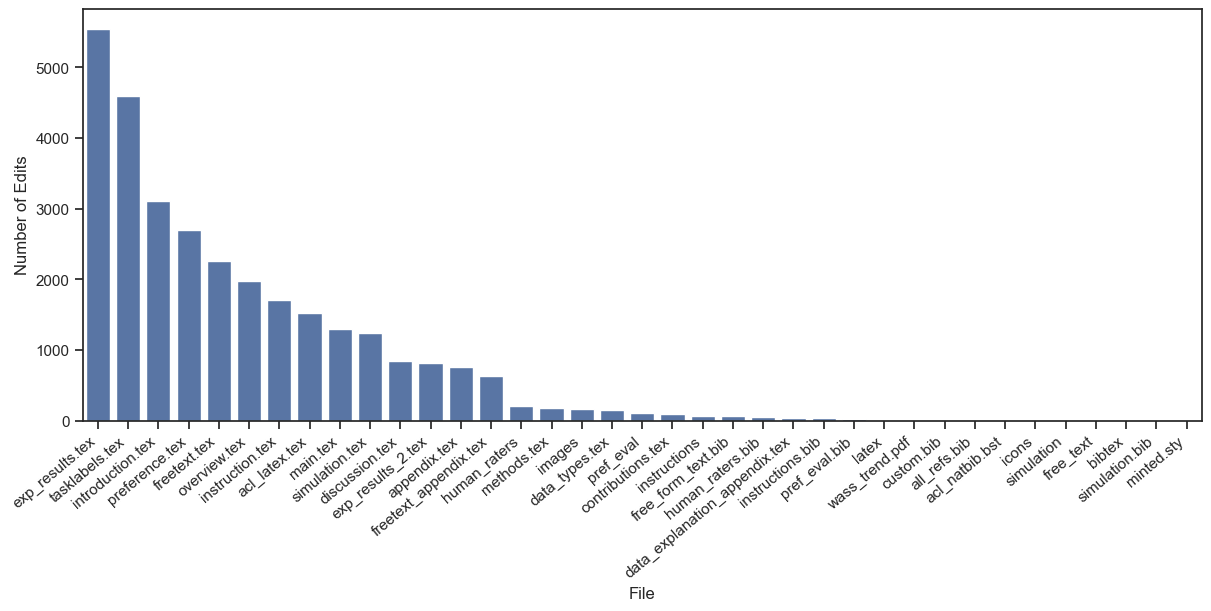

In [47]:
fig, (ax1) = plt.subplots(1, 1, constrained_layout = True,  figsize=(12,6)) 

ax1 = sns.barplot(df["file"].value_counts(), ax=ax1)
ax1.set(xlabel='File', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_by_file.png")



In [48]:
# can manually check this to see if it is the one that you want
main_filename = df["file"].value_counts().idxmax()

print(main_filename)

df_main = df.loc[df["file"] == main_filename].reset_index()

idx = 2

state = df_main.iloc[idx]["state"]
fname = df_main.iloc[idx]["file"]
text = df_main.iloc[idx]["text"]
changes = df_main.iloc[idx]["changes"]
revision = df_main.iloc[idx]["revision"]
editingLines = df_main.iloc[idx]["editingLines"]
line = df_main.iloc[idx]["line"]



print("length", len(text))
print("total lines", text.count("\n") + 1)
print("also total lines", len(editingLines))
print("absolute line", line)

print("\n\n\n")
get_section_edited(text, line, editingLines)

exp_results.tex
length 816
total lines 13
also total lines 13
absolute line 2






'Unknown/unfamiliar situations: Instructions'

def recreate_text(revision_arr):

In [49]:
def recreate_text(revision_arr):
    text = ""
    for diff in revision_arr:
        op, data = diff[:2]
        
        if op == 0 or op == 1:
            text += data
        elif op == 2:
            raise Exception("illegal operations in diff")

    return text
        

/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_96673/562875236.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



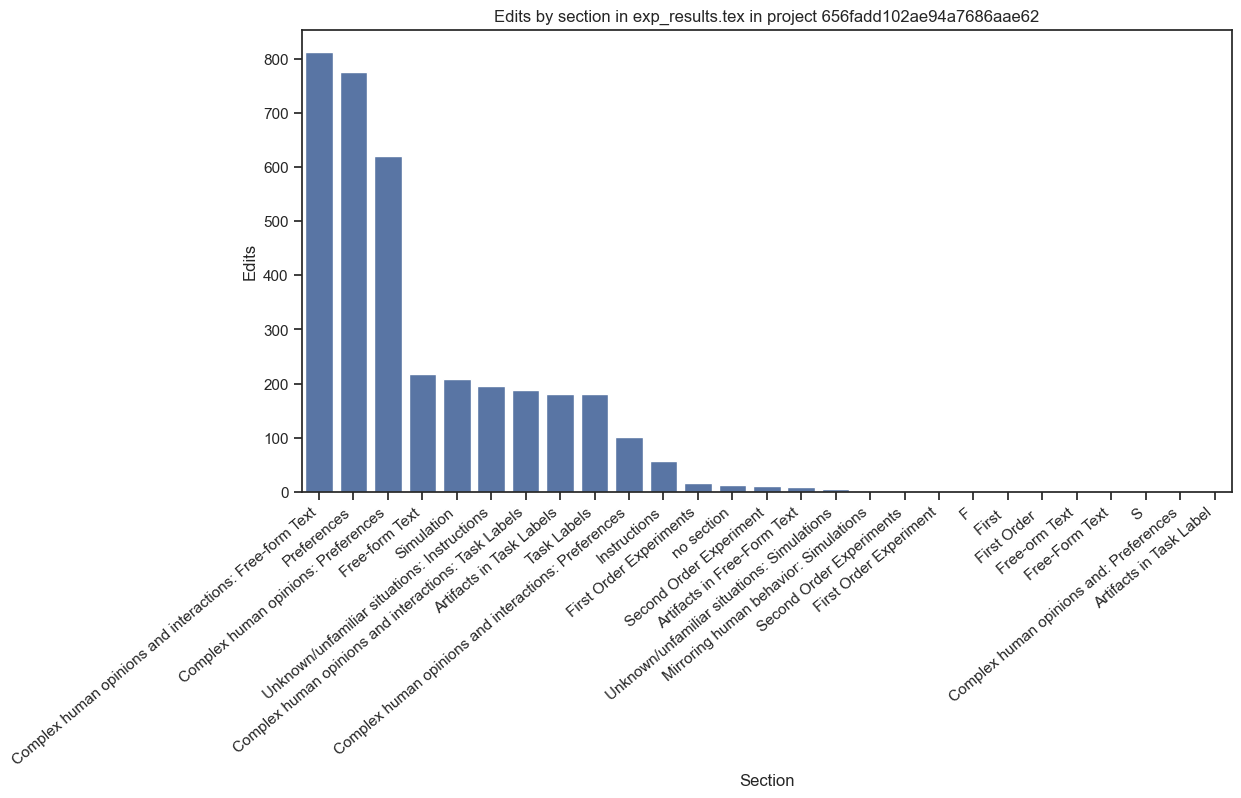

In [50]:
df_main["full_text"] = df_main.apply(lambda x: recreate_text(x["revision"]), axis=1)

df_main["section"] = df_main.apply(lambda x: get_section_edited(x["full_text"], x["line"], x["editingLines"]), axis=1)

fig, ax = plt.subplots(figsize=(12, 6)) 

sns.barplot(df_main["section"].value_counts(), ax=ax)
ax.set_title(f'Edits by section in {main_filename} in project {project_id}')
ax.set(xlabel='Section', ylabel='Edits')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

df_main.head()

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


section        Artifacts in Free-Form Text  Artifacts in Task Label  \
timestamp                                                             
1702654203716                            0                        0   
1702654203739                            0                        0   
1702654205369                            0                        0   
1702654219568                            0                        0   
1702654219585                            0                        0   

section        Artifacts in Task Labels  \
timestamp                                 
1702654203716                         0   
1702654203739                         0   
1702654205369                         0   
1702654219568                         0   
1702654219585                         0   

section        Complex human opinions and interactions: Free-form Text  \
timestamp                                                                
1702654203716                                       

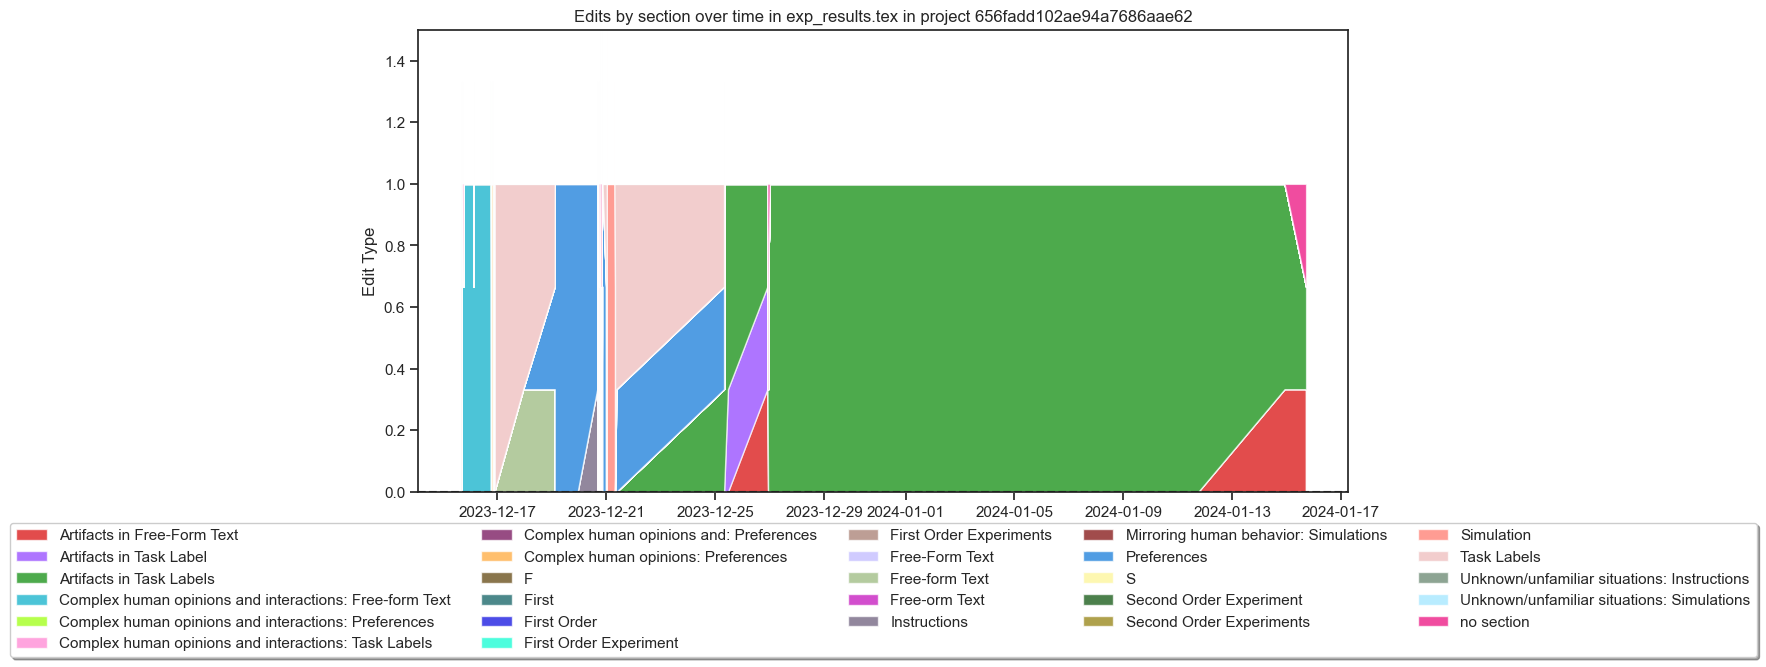

In [51]:
pivot_df = pd.pivot_table(df_main, index="timestamp", columns="section", aggfunc="size", fill_value=0)
print(pivot_df.head())

window_size = 3  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title(f'Edits by section over time in {main_filename} in project {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_over_time.png")


In [52]:
#cb_df = df.loc[df["cb"].notnull()]
#cb_df = df.loc[df["message"].isin(["paste", "Paste"])]
df_main["cb_counts"] =  df_main["changes"].apply(lambda x: 0 if type(x) is not str else len(x))
df_main.head()



,index,_id,timestamp,text,revision,state,line,username,project,file,...,message,changes,clipboard,cb,line_counts,edits,cum_edits,full_text,section,cb_counts
0,15730,657c70fc699d8f6253cb298f,1702654203739,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Paste,[All lines are the same],Instruction prompts are used to refine the per...,NaN,13,353,73357841,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
1,15731,657c70fc699d8f6253cb2990,1702654203716,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, About ...",UndoRedo,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,UndoRedo,"[(2,0) \subsection{About this Data Type}\label...",NaN,NaN,13,2753,73360594,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
2,15732,657c70fd699d8f6253cb2991,1702654205369,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Paste,"[(2,0) \n->Instruction prompts are used to ref...",Instruction prompts are used to refine the per...,NaN,13,816,73361410,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
3,15735,657c710b699d8f6253cb2994,1702654219585,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Typing,3,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Typing,"[(3,0), \n---added]",NaN,NaN,14,817,73367679,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
4,15736,657c710b699d8f6253cb2995,1702654219568,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, Ab, 1]...",Typing,5,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Typing,"[(5,53), LLM, wit---deleted, (5,50), with a la...",NaN,NaN,14,2772,73370451,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0


0       0
1       0
2       0
3       0
4       0
       ..
5541    0
5542    0
5543    0
5544    0
5545    0
Name: cb_counts, Length: 5546, dtype: int64


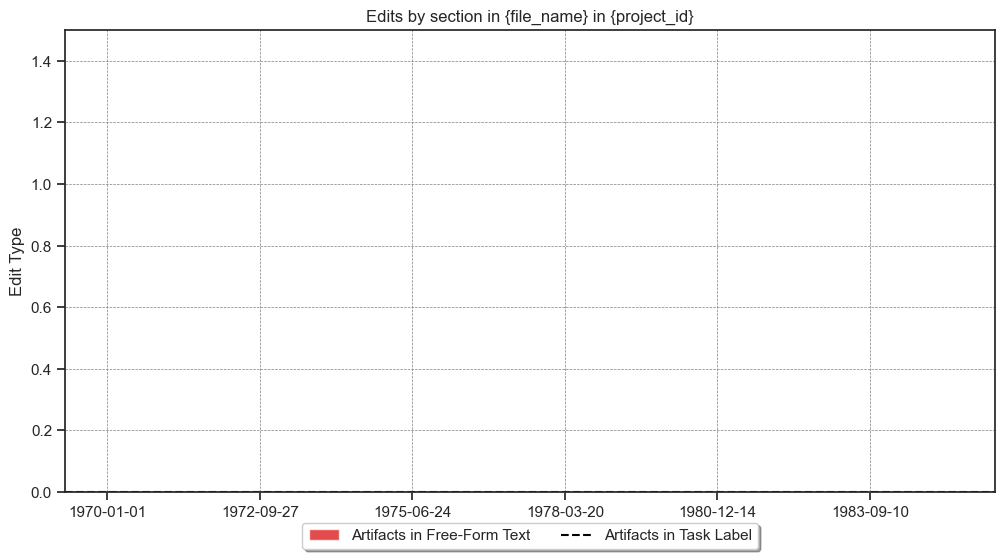

In [53]:
fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

print(df_main["cb_counts"])


ax.stackplot(df_main.index, df_main["cb_counts"], alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title('Edits by section in {file_name} in {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)



ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


In [54]:
df_main.head()

,index,_id,timestamp,text,revision,state,line,username,project,file,...,message,changes,clipboard,cb,line_counts,edits,cum_edits,full_text,section,cb_counts
0,15730,657c70fc699d8f6253cb298f,1702654203739,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Paste,[All lines are the same],Instruction prompts are used to refine the per...,NaN,13,353,73357841,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
1,15731,657c70fc699d8f6253cb2990,1702654203716,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, About ...",UndoRedo,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,UndoRedo,"[(2,0) \subsection{About this Data Type}\label...",NaN,NaN,13,2753,73360594,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
2,15732,657c70fd699d8f6253cb2991,1702654205369,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Paste,"[(2,0) \n->Instruction prompts are used to ref...",Instruction prompts are used to refine the per...,NaN,13,816,73361410,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
3,15735,657c710b699d8f6253cb2994,1702654219585,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Typing,3,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Typing,"[(3,0), \n---added]",NaN,NaN,14,817,73367679,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0
4,15736,657c710b699d8f6253cb2995,1702654219568,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, Ab, 1]...",Typing,5,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Typing,"[(5,53), LLM, wit---deleted, (5,50), with a la...",NaN,NaN,14,2772,73370451,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0


In [55]:
df_main["additions"] = df_main.apply(lambda x: count_op(1, x["revision"]), axis=1)
df_main["deletions"] = df_main.apply(lambda x: count_op(-1, x["revision"]), axis=1)
df_main.head()

,index,_id,timestamp,text,revision,state,line,username,project,file,...,clipboard,cb,line_counts,edits,cum_edits,full_text,section,cb_counts,additions,deletions
0,15730,657c70fc699d8f6253cb298f,1702654203739,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Instruction prompts are used to refine the per...,NaN,13,353,73357841,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0,0,0
1,15731,657c70fc699d8f6253cb2990,1702654203716,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, About ...",UndoRedo,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,NaN,NaN,13,2753,73360594,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0,73,-2400
2,15732,657c70fd699d8f6253cb2991,1702654205369,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Paste,2,karin,656fadd102ae94a7686aae62,exp_results.tex,...,Instruction prompts are used to refine the per...,NaN,13,816,73361410,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0,463,0
3,15735,657c710b699d8f6253cb2994,1702654219585,\section{Unknown/unfamiliar situations: Instru...,"[[0, \section{Unknown/unfamiliar situations: I...",Typing,3,karin,656fadd102ae94a7686aae62,exp_results.tex,...,NaN,NaN,14,817,73367679,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0,1,0
4,15736,657c710b699d8f6253cb2995,1702654219568,\section{Unknown/unfamiliar situations: Instru...,"[[0, \s], [-1, ubs], [0, ection{], [-1, Ab, 1]...",Typing,5,karin,656fadd102ae94a7686aae62,exp_results.tex,...,NaN,NaN,14,2772,73370451,\section{Unknown/unfamiliar situations: Instru...,Unknown/unfamiliar situations: Instructions,0,92,-1956


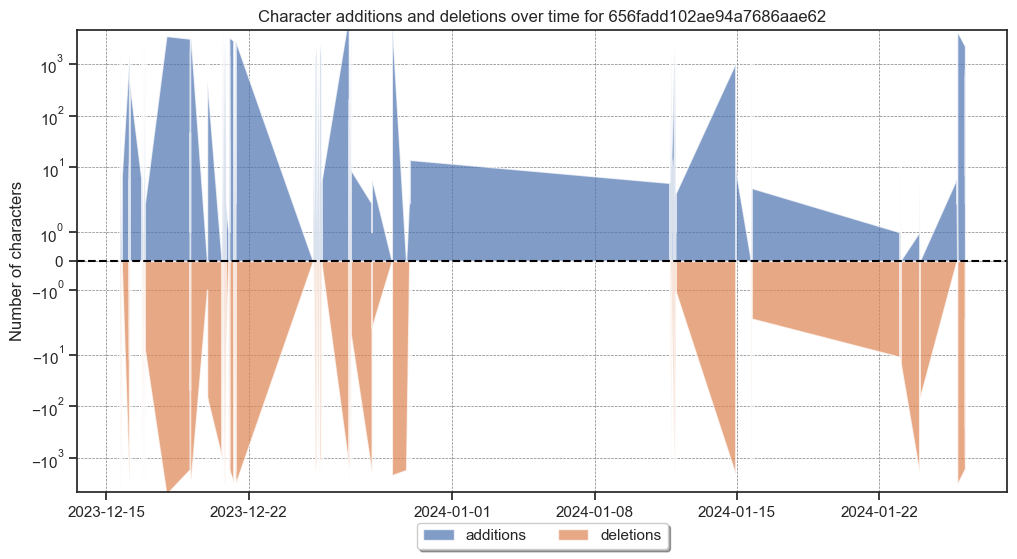

In [56]:
#pivot_df = pd.pivot_table(df1, index="timestamp", values="additions", aggfunc="size", fill_value=0)


df_main.index = pd.to_datetime(df_main["timestamp"], unit="ms")

#window_size = 1  # Adjust the window size as needed
#df1[["additions", "deletions"]] = df1[["additions", "deletions"]].rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
#colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

#ax.set_prop_cycle('color', colors)

ax.stackplot(df_main.index, df_main["additions"], alpha=0.7, baseline="zero")
ax.stackplot(df_main.index, df_main["deletions"], alpha=0.7, baseline="zero")


# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Number of characters')
ax.set_title(f'Character additions and deletions over time for {project_id}')
ax.set_yscale("symlog")
ax.set_ylim((-4500, 4500))

ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)


ax.legend(df_main[["additions", "deletions"]],loc='upper center', bbox_to_anchor=(0.5, -0.05),fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_additions_deletions_over_time.png")


In [57]:
def check(df):
    if (df["file"] == df["next_file"]):
        return "null"
    else:
        return df["next_file"]

df.head()
df["next_file"] = df["file"].shift(1)
df["next_file"] = df.apply(check, axis = 1)

In [58]:
#df["next_file"].value_counts()
import plotly as px

#labels = list(i for i in df["next_file"].unique() if i != None and i != "null")

labels = [col for col in df["next_file"].unique() if (col != None and col != "null") and ('.tex' in col or '.bib' in col)]


n_colors = int(len(labels))
colors = px.colors.sample_colorscale("turbo", [n/(n_colors -1) for n in range(n_colors)])
colors += colors


source = []
target = []
value = []
line_colors = []

for start_idx, start in enumerate(labels):
    for end_idx, end in enumerate(labels):
        if (start == end):
            # this one should already by filtered
            continue

        volume = len(df.loc[(df['file'] == start) & (df['next_file'] == end)])

        if (volume <= 0.01):
            continue
        
        source.append(start_idx)
        target.append(end_idx + len(labels))
        value.append(volume)
        line_colors.append(colors[start_idx])

labels += labels




        

In [59]:
for i in range(len(line_colors)):
    line_colors[i] = line_colors[i][0:-1] + ", 0.5)"
    line_colors[i] = line_colors[i].replace("rgb", "rgba")
    print(line_colors[i])
    

rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(48, 18, 59, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(58, 48, 124, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(66, 77, 182, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(69, 105, 220, 0.5)
rgba(66, 132, 242, 0.5)
rgba(66, 132, 24

In [60]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 1),
      label = labels,
      color = colors
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value,
      color=line_colors
  ))],
    layout = dict(
        height = 800,
        width = 800
    ))

fig.update_layout(title_text="Changes in Edited files in project: " + project_id, font_size=10)
fig.write_image(f"sankey_{project_id}.png")

fig.write_image(f"figures/{project_id}_writing_flow_sankey.png")

fig.show()


